In [1]:
import re
import pandas as pd
from typing import Iterable
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
import hdbscan
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from collections import defaultdict, deque
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## BERTopic

embedding lyrics -> umap reduction -> hdbscan/kmeans

In [2]:
# lemmatizer
lemmatizer = WordNetLemmatizer()             
    
# stopwords
base_sw = set(stopwords.words("english"))
negations = {"no", "not", "nor", "never"}
sw = base_sw - negations
sw |= {
    "yeah", "uh", "la", "oh", "ooh", "na", "nah", "hey", "yo", "ha", "whoa",
    "mmm", "woo", "like", "shit", "go", "get", "know", "want"
}

# helper functions
TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?")
BRACKETS_RE = re.compile(r"\[[^\]]*\]")

def clean(doc: str, min_token_len: int = 2, remove_digits_only: bool = True) -> str:
    """
    - expand contractions, strip, and turn into lowercase
    - removed bracketed text
    - tokenize
    - remove stopwords, short tokens, and digits
    - lemmatize
    - join the tokens
    """
    if not isinstance(doc, str):
        return ""
    text = contractions.fix(doc).strip().lower()
    text = BRACKETS_RE.sub(" ", text)
    toks = TOKEN_RE.findall(text)
    toks = [t for t in toks
            if (t not in sw)
            and (len(t) >= min_token_len)
            and (not (remove_digits_only and t.isdigit()))]
    lemma = []
    for t in toks:
        n = lemmatizer.lemmatize(t, pos="n")
        v = lemmatizer.lemmatize(n, pos="v")
        lemma.append(v)

    return " ".join(lemma)

def preprocess(texts: Iterable[str]) -> pd.Series:
    """
    - perform text cleaning
    - return a series
    """
    return pd.Series([clean(t) for t in texts], index=getattr(texts, "index", None))

def get_lyrics(pop, idx, lyrics, topic_model, top_n=5, exclude_outliers=True):
    """
    - get indices of lyrics
    - get topic labels
    - print the representative lyrics for each topic
    """
    pos_map = defaultdict(deque)
    for i, text in enumerate(lyrics):
        pos_map[text].append(i)

    info = topic_model.get_topic_info()
    topic_ids = info["Topic"].tolist()
    if exclude_outliers:
        topic_ids = [t for t in topic_ids if t != -1]

    for t in topic_ids:
        reps = topic_model.get_representative_docs(t)[:top_n]
        print(f"\n=== Topic {t} ===")
        for d in reps:
            if pos_map[d]:
                doc_idx = pos_map[d].popleft()        
                orig_index = idx[doc_idx]          
                print(f"[row {orig_index}]")
                print(pop.loc[orig_index, "lyrics"])
            else:
                print("[unmapped] (showing processed text)")
                print(d)
            print("-" * 60)

In [3]:
# preprocess the lyrics
pop_filtered = pop.dropna(subset=["lyrics"])
pop_filtered["processed_lyrics"] = preprocess(pop_filtered["lyrics"])
corpus = pop_filtered["processed_lyrics"].astype(str).str.strip()
mask = corpus.ne("")                       
lyrics = corpus[mask].tolist()
idx  = corpus[mask].index

2 Topics: HBDSCAN + BERTopic 

In [4]:
# set up BERTopic
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer_model = CountVectorizer(
    lowercase=False,             
    token_pattern=r"(?u)\b\w+\b",
    stop_words=list(sw),         
    ngram_range=(1, 2),          
    min_df=0.01                     
)

umap_model = UMAP(
    n_neighbors=160,
    min_dist=0,
    n_components=2,
    metric="cosine",
    random_state=13
) 

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=400,
    min_samples=1,
    cluster_selection_epsilon=0.2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

# fit the model
X = embedding_model.encode(lyrics, show_progress_bar=True, normalize_embeddings=True)
topics, probs = topic_model.fit_transform(lyrics, X)
topic_model.get_topic_info()


Batches: 100%|██████████| 291/291 [01:02<00:00,  4.64it/s]
2025-09-05 01:57:29,585 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-09-05 01:58:07,124 - BERTopic - Dimensionality - Completed ✓
2025-09-05 01:58:07,126 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-05 01:58:07,308 - BERTopic - Cluster - Completed ✓
2025-09-05 01:58:07,315 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-09-05 01:58:09,095 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1674,-1_not_love_no_say,"[not, love, no, say, make, baby, come, one, le...",[first would say good even please many could c...
1,0,6120,0_not_love_no_let,"[not, love, no, let, baby, say, make, time, fe...",[pullin makin stronger shakin right core not s...
2,1,1496,1_not_nigga_bitch_fuck,"[not, nigga, bitch, fuck, no, make, say, back,...",[bo ale dojeba bite new york stand fuck go nig...


In [14]:
# view representative lyrics
get_lyrics(pop, idx, lyrics, topic_model, top_n=5)


=== Topic 0 ===
[row 4928]
pullin' me further, further than i've been before makin' me stronger, shakin' me right to the core oh, i don't know what's in the stars never heard it from above, the world isn't ours but i know what's in my heart if you ain't mine, i'll be torn apart i don't know who's gonna kiss you when i'm gone so i'm gonna love you now like it's all i have i know it'll kill me when it's over i don't wanna think about it, i want you to love me now i don't know who's gonna kiss you when i'm gone so i'm gonna love you now like it's all i have i know it'll kill me when it's over i don't wanna think about it, i want you to love me now (love me now, love me now) oh, oh, love me now, oh, oh, oh, yeah (love me now, love me now) i want you to love me now somethin' inside us knows there's nothing guaranteed yeah, girl, i don't need you to tell me that you'll never leave, no when we've done all that we could to turn darkness into light, turn evil to good even when we try so hard f

I adjusted the hyperparameters for UMAP and HBDSCAN to reduce noise and produce interpretable topics.<br>
Topic 0 seems to be about the difficult feelings in romance.<br>
Topic 1 seems to be rap/hip-hop.

2 Topics: KMeans + BERTopic

In [15]:
# set up BERTopic
K = 2  

kmeans_model = KMeans(
    n_clusters=K,
    n_init=10,         
    random_state=13
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=kmeans_model,  
    calculate_probabilities=False,
    verbose=True
)

# fit the model
X = embedding_model.encode(lyrics, show_progress_bar=True, normalize_embeddings=True)
topics, _ = topic_model.fit_transform(lyrics, X)
topic_model.get_topic_info()


Batches: 100%|██████████| 291/291 [01:02<00:00,  4.66it/s]
2025-08-29 02:00:36,475 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-29 02:01:07,937 - BERTopic - Dimensionality - Completed ✓
2025-08-29 02:01:07,938 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-08-29 02:01:08,442 - BERTopic - Cluster - Completed ✓
2025-08-29 02:01:08,451 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-08-29 02:01:10,557 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,5096,0_not_love_no_say,"[not, love, no, say, never, feel, let, make, t...",[not love not forget silly phase go call not w...
1,1,4194,1_not_no_nigga_say,"[not, no, nigga, say, make, bitch, baby, come,...",[woah bitch ayy damn bitch ayy motherfucking f...


In [16]:
# view representative lyrics
get_lyrics(pop, idx, lyrics, topic_model, top_n=5)


=== Topic 0 ===
[row 3975]
i'm not in love, so don't forget it it's just a silly phase i'm going through and just because i call you up don't get me wrong, don't think you've got it made i'm not in love, no no it's because i like to see you, but then again that doesn't mean you mean that much to me so if i call you, don't make a fuss don't tell your friends about the two of us i'm not in love, no no it's because ooh, you'll wait a long time for me ooh, you'll wait a long time ooh, you'll wait a long time for me ooh, you'll wait a long time i'm not in love, so don't forget it it's just a silly phase i'm going through and just because i call you up don't get me wrong, don't think you've got it made i'm not in love i'm not in love
------------------------------------------------------------
[row 3723]
not everyone gets drunk without a drop of wine or a sip of 90 proof, but i do not everybody loves getting caught at red lights they got no one to lean into, but i do you don't know how many

I used KMeans to create 2 clusters for BERTopic.<br>
Topic 0 seems to include the love songs.<br>
Topic 1 seems to be rap/hip-hop.<br>
The results echo what we got from HBDSCAN but Topic 0 could be less emotionally nuanced due to the forced clustering.

3 Topics: HBDSCAN + BERTopic 

In [19]:
# set up BERTopic
umap_model = UMAP(
    n_neighbors=15,
    min_dist=0.01,
    n_components=6,
    metric="cosine",
    random_state=13
) 

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

# fit the model
X = embedding_model.encode(lyrics, show_progress_bar=True, normalize_embeddings=True)
topics, probs = topic_model.fit_transform(lyrics, X)
topic_model.get_topic_info()


Batches: 100%|██████████| 291/291 [01:02<00:00,  4.69it/s]
2025-08-29 15:50:45,968 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-29 15:50:56,614 - BERTopic - Dimensionality - Completed ✓
2025-08-29 15:50:56,616 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-29 15:50:57,029 - BERTopic - Cluster - Completed ✓
2025-08-29 15:50:57,036 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-08-29 15:50:59,316 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2977,-1_not_love_no_say,"[not, love, no, say, let, make, baby, time, ta...",[girl give writer's block loss word uhh mind's...
1,0,2780,0_not_love_no_feel,"[not, love, no, feel, never, say, let, would, ...",[would tell love tonight get time side go leav...
2,1,2470,1_not_nigga_bitch_no,"[not, nigga, bitch, no, fuck, say, make, back,...",[cool dre simple complicate complicate think m...
3,2,1063,2_not_night_baby_girl,"[not, night, baby, girl, love, little, back, o...",[not dare runnin little town grow not cuss cit...


In [20]:
# view representative lyrics
get_lyrics(pop, idx, lyrics, topic_model, top_n=5)


=== Topic 0 ===
[row 8725]
ooh-ooh, ooh-ooh ooh-ooh, ooh-ooh i would tell you that i love you tonight but i know that i've got time on my side where you goin'? why you leavin' so soon? is there somewhere else that’s better for you? what is love if you're not here with me? what is love if it's not guaranteed? what is love if it just ups and leaves? what is love if you're not here no more? what is love if you're not really sure? what is love? what is love? tell myself i wouldn't cry when you're gone but i know it's easier said than done look at me, look at me choked up now (lookin' choked up now) try to tell you, but it won't come out what is love if you're not here with me? what is love if it's not guaranteed? what is love if it just ups and leaves? what is love if you're not here no more? what is love if you're not really sure? what is love if it just ups and goes? i can't live without ya (i can't live without ya) i can’t live with ya (i can't live with ya) what goes around will come 

I adjusted the hyperparameters for UMAP and HBDSCAN, following the logic of the 2-topic setup.<br>
Topic 0 seems to be about the difficult feelings in romance.<br>
Topic 1 seems to be rap/hip-hop.<br>
Topic 2 seems to be country.

3 Topics: KMeans + BERTopic 

In [23]:
# set up BERTopic
K = 3

kmeans_model = KMeans(
    n_clusters=K,
    n_init=10,         
    random_state=13
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=kmeans_model,  
    calculate_probabilities=False,
    verbose=True
)

# fit the model
X = embedding_model.encode(lyrics, show_progress_bar=True, normalize_embeddings=True)
topics, _ = topic_model.fit_transform(lyrics, X)
topic_model.get_topic_info()

Batches: 100%|██████████| 291/291 [01:03<00:00,  4.55it/s]
2025-08-29 16:02:19,124 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-29 16:02:29,990 - BERTopic - Dimensionality - Completed ✓
2025-08-29 16:02:29,993 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-29 16:02:30,064 - BERTopic - Cluster - Completed ✓
2025-08-29 16:02:30,075 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-08-29 16:02:32,917 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,4332,0_not_love_no_feel,"[not, love, no, feel, never, say, let, cannot,...",[wish could could say goodbye would say want m...
1,1,2759,1_not_love_baby_come,"[not, love, baby, come, no, girl, let, night, ...",[woah fall love not feel hard meet need time a...
2,2,2199,2_not_nigga_bitch_no,"[not, nigga, bitch, no, fuck, say, make, back,...",[bo ale dojeba beat new york stand fuck go nig...


In [24]:
# view representative lyrics
get_lyrics(pop, idx, lyrics, topic_model, top_n=5)


=== Topic 0 ===
[row 3949]
wish i could, i could've said goodbye i would've said what i wanted to maybe even cried for you if i knew, it would be the last time i would've broke my heart in two tryin' to save a part of you don't want to feel another touch don't wanna start another fire don't wanna know another kiss no other name falling off my lips don't wanna to give my heart away to another stranger or let another day begin won't even let the sunlight in no, i'll never love again i'll never love again ooouuu ooou oou oh when we first met i never thought that i would fall i never thought that i'd find myself lying in your arms and i want to pretend that it's not true oh baby, that you're gone 'cause my world keeps turning, and turning, and turning and i'm not movin' on don't want to feel another touch don't wanna start another fire don't wanna know another kiss no other name falling off my lips don't wanna give my heart away to another stranger or let another day begin won't even let 

I used KMeans to create 3 clusters for BERTopic.<br>
Topic 0 seems to be about the difficult feelings in romance.<br>
Topic 1 seems to be a combination of love songs & rap/hip-pop. <br>
Topic 2 seems to be rap/hip-hop.<br>
The results echo what we got from HBDSCAN but there are no country songs and Topic 1 lumps together different genres.


Overall, a comparison of the 2-topic setup and the 3-topic setup shows two general themes: love songs & rap/hip-pop. <br>
Depending on the clustering method, many love songs convey sadness, frustration, or longing.

### Factor Analysis on Large Corpus of Pop Lyrics

I revised the original code for removing low-loading variables. First, I set the threshold to 0.3 and keep looping until all variables have loading scores above the threshold. This step filters out the irrelevant items. Then I increase the threshold to 0.6 and continue looping until the items remain unchanged and stabilized. This step picks out the highly important items.

In [ ]:
songs= pd.read_csv("songs_liwc.csv")
songs.columns

In [ ]:
# Find index of "Text" column
idx = songs.columns.get_loc("Segment")

# Select all columns after it
scores = songs.iloc[:, idx + 1 :]

scores = scores.dropna()

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

threshold = 1e-5
selector = VarianceThreshold(threshold=threshold)
liwc_reduced = selector.fit_transform(scores)

# Keep only retained columns
kept_columns = scores.columns[selector.get_support()]
liwc_reduced = pd.DataFrame(liwc_reduced, columns=kept_columns)

print(f"After variance filtering: {liwc_reduced.shape}")
print("Dropped columns:", set(scores.columns) - set(kept_columns))

scaler = StandardScaler()
scores_scaled = pd.DataFrame(
    scaler.fit_transform(liwc_reduced),
    columns=liwc_reduced.columns,
)

print(f"After standardization: {scores_scaled.shape}")
scores_scaled.head()

In [105]:
from factor_analyzer import FactorAnalyzer
import pandas as pd
import numpy as np

# Work on a copy for iterative elimination
pop_num_concise = scores_scaled.copy()

n_factors = 2
threshold = 0.3            # starting threshold
high_threshold = 0.6       # higher threshold once things stabilize
max_rounds = 20            # safety cap
switched_to_high = False   # flag to track when we move to 0.6
final_loadings_df = None   # to store loadings for final round

for round_num in range(1, max_rounds + 1):
    print(f"\n--- Round {round_num} (threshold = {threshold}) ---")
    print(f"Number of variables entering FA: {pop_num_concise.shape[1]}")

    # Fit Factor Analysis
    fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
    fa.fit(pop_num_concise)

    # Get loadings
    loadings = fa.loadings_
    loadings_df = pd.DataFrame(
        loadings,
        index=pop_num_concise.columns,
        columns=[f"Factor{i+1}" for i in range(n_factors)]
    )

    # Save for final display (updated each iteration)
    final_loadings_df = loadings_df.copy()

    # Show top 6 variables by max absolute loading
    loadings_df["max_abs_loading"] = loadings_df.abs().max(axis=1)
    top6 = loadings_df.sort_values("max_abs_loading", ascending=False).head(6)

    print("\nTop 6 variables this round (by max |loading|):")
    print(top6.drop(columns="max_abs_loading"))

    # Identify low-loading items under current threshold
    low_loading_items = [
        pop_num_concise.columns[i]
        for i in range(loadings.shape[0])
        if np.all(np.abs(loadings[i, :]) < threshold)
    ]

    print(f"\nLow-loading items (all |loadings| < {threshold}): {low_loading_items}")

    if not low_loading_items:
        # No variables removed at this threshold
        if not switched_to_high and threshold < high_threshold:
            # First time we hit stability at low threshold → increase to high threshold
            print(
                f"No variables removed at threshold {threshold}. "
                f"Increasing threshold to {high_threshold} for stricter pruning."
            )
            threshold = high_threshold
            switched_to_high = True
            continue
        else:
            # Already at high threshold and still nothing to remove → stabilized
            print(
                f"No variables removed at threshold {threshold}. "
                "Model considered stabilized. Stopping."
            )
            break

    # Drop low-loading items and continue
    pop_num_concise.drop(columns=low_loading_items, inplace=True)
    print(f"Remaining columns after round {round_num}:")
    print(pop_num_concise.columns.tolist())

# === Final ranked output ===
print("\n=== Final set of variables ranked by max |loading| ===")
final_loadings_df["max_abs_loading"] = final_loadings_df.abs().max(axis=1)
ranked = final_loadings_df.sort_values("max_abs_loading", ascending=False)
print(ranked.drop(columns="max_abs_loading"))


--- Round 1 (threshold = 0.3) ---
Number of variables entering FA: 117


/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Top 6 variables this round (by max |loading|):
             Factor1   Factor2
Cognition   0.811446 -0.008254
Linguistic  0.807193 -0.031497
function    0.798430 -0.103432
Analytic   -0.766895 -0.324701
Social      0.192914  0.730392
verb        0.710558  0.034090

Low-loading items (all |loadings| < 0.3): ['WC', 'Tone', 'WPS', 'BigWords', 'we', 'shehe', 'they', 'ipron', 'det', 'number', 'conj', 'adj', 'quantity', 'Drives', 'affiliation', 'achieve', 'power', 'allnone', 'cause', 'certitude', 'memory', 'tone_neg', 'emo_neg', 'emo_anx', 'emo_anger', 'emo_sad', 'prosocial', 'polite', 'conflict', 'moral', 'comm', 'family', 'friend', 'female', 'male', 'Culture', 'politic', 'ethnicity', 'tech', 'Lifestyle', 'leisure', 'home', 'work', 'money', 'relig', 'Physical', 'health', 'illness', 'wellness', 'mental', 'substances', 'sexual', 'food', 'death', 'need', 'want', 'acquire', 'lack', 'fulfill', 'fatigue', 'reward', 'risk', 'curiosity', 'allure', 'attention', 'motion', 'visual', 'auditory', 'feeli

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Top 6 variables this round (by max |loading|):
             Factor1   Factor2
Social      0.158217  0.813039
Linguistic  0.810782  0.001781
function    0.791620 -0.017848
Cognition   0.788939  0.023124
Analytic   -0.777756 -0.302074
verb        0.713434  0.039208

Low-loading items (all |loadings| < 0.3): ['prep', 'swear', 'Conversation', 'AllPunc']
Remaining columns after round 2:
['Analytic', 'Clout', 'Authentic', 'Dic', 'Linguistic', 'function', 'pronoun', 'ppron', 'i', 'you', 'article', 'auxverb', 'adverb', 'negate', 'verb', 'Cognition', 'cogproc', 'insight', 'discrep', 'tentat', 'differ', 'Affect', 'tone_pos', 'emotion', 'emo_pos', 'Social', 'socbehav', 'socrefs', 'Perception', 'space', 'focuspresent']

--- Round 3 (threshold = 0.3) ---
Number of variables entering FA: 31


...


Top 6 variables this round (by max |loading|):
             Factor1   Factor2
Social      0.155046  0.837832
Linguistic  0.803275  0.026165
Analytic   -0.791935 -0.257238
Cognition   0.781004  0.010403
function    0.775262  0.022829
verb        0.714499  0.033906

Low-loading items (all |loadings| < 0.3): []
No variables removed at threshold 0.3. Increasing threshold to 0.6 for stricter pruning.

--- Round 5 (threshold = 0.6) ---
Number of variables entering FA: 30


/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Top 6 variables this round (by max |loading|):
             Factor1   Factor2
Social      0.155046  0.837832
Linguistic  0.803275  0.026165
Analytic   -0.791935 -0.257238
Cognition   0.781004  0.010403
function    0.775262  0.022829
verb        0.714499  0.033906

Low-loading items (all |loadings| < 0.6): ['Clout', 'Authentic', 'i', 'you', 'article', 'adverb', 'negate', 'insight', 'discrep', 'differ', 'Affect', 'tone_pos', 'emotion', 'emo_pos', 'socbehav', 'Perception', 'space', 'focuspresent']
Remaining columns after round 5:
['Analytic', 'Dic', 'Linguistic', 'function', 'pronoun', 'ppron', 'auxverb', 'verb', 'Cognition', 'cogproc', 'Social', 'socrefs']

--- Round 6 (threshold = 0.6) ---
Number of variables entering FA: 12

Top 6 variables this round (by max |loading|):
             Factor1   Factor2
socrefs     0.028012  0.856480
Social      0.046059  0.849845
Linguistic  0.826483  0.162893
Cognition   0.799670  0.016394
function    0.769705  0.196318
verb        0.745133  0.101602


/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Top 6 variables this round (by max |loading|):
             Factor1   Factor2
Social      0.104000  0.988437
socrefs     0.104510  0.847799
Linguistic  0.835625  0.092930
Cognition   0.813344  0.009321
function    0.773369  0.110977
verb        0.759343  0.076762

Low-loading items (all |loadings| < 0.6): []
No variables removed at threshold 0.6. Model considered stabilized. Stopping.

=== Final set of variables ranked by max |loading| ===
             Factor1   Factor2
Social      0.104000  0.988437
socrefs     0.104510  0.847799
Linguistic  0.835625  0.092930
Cognition   0.813344  0.009321
function    0.773369  0.110977
verb        0.759343  0.076762
Dic         0.723624  0.201040
Analytic   -0.699196 -0.238885
auxverb     0.690432  0.067398
cogproc     0.622223  0.043260


In [106]:
# Prepare for Factor Analysis on the smaller set of columns
scores_scaled = pop_num_concise

#does it do better than identity matrix?
chi_square_value, p_value = calculate_bartlett_sphericity(scores_scaled)
print("Bartlett’s Test: p =", p_value, "Chi-square =", chi_square_value)

#KMO calculations
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(scores_scaled)
kmo_model # 0.6 is not very good, 0.7 is acceptable, 0.8 is good, 0.9 is great

Bartlett’s Test: p = 0.0 Chi-square = 109853.6085375957


0.7469861992941961

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


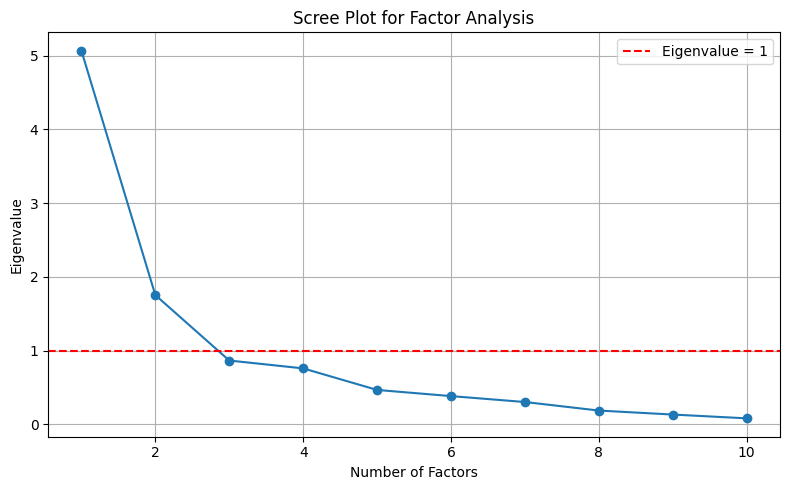

In [107]:
# determine the number of factors
import matplotlib.pyplot as plt

# Fit FactorAnalyzer with max possible factors
fa = FactorAnalyzer(n_factors=scores_scaled.shape[1], rotation='varimax')
fa.fit(scores_scaled)

# Get eigenvalues and plot them
ev, _ = fa.get_eigenvalues()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ev)+1), ev, marker='o', linestyle='-')
plt.axhline(1, color='red', linestyle='--', label='Eigenvalue = 1')
plt.title('Scree Plot for Factor Analysis')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [108]:
# factor analysis with 2 factors
fa = FactorAnalyzer(n_factors=2, rotation='varimax') 
fa.fit(scores_scaled)

# Get the variance explained
variance, proportion_variance, cumulative_variance = fa.get_factor_variance()

# Print variance results
print("Variance per factor:", variance)
print("Proportion of variance per factor:", proportion_variance)
print("Cumulative variance (proportion):", cumulative_variance)

Variance per factor: [4.43260041 1.82659973]
Proportion of variance per factor: [0.44326004 0.18265997]
Cumulative variance (proportion): [0.44326004 0.62592001]


/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[            Factor 1  Factor 2
Social      0.104000  0.988437
socrefs     0.104510  0.847799
Dic         0.723624  0.201040
function    0.773369  0.110977
Linguistic  0.835625  0.092930
verb        0.759343  0.076762
auxverb     0.690432  0.067398
cogproc     0.622223  0.043260
Cognition   0.813344  0.009321
Analytic   -0.699196 -0.238885]


<Figure size 1000x600 with 0 Axes>

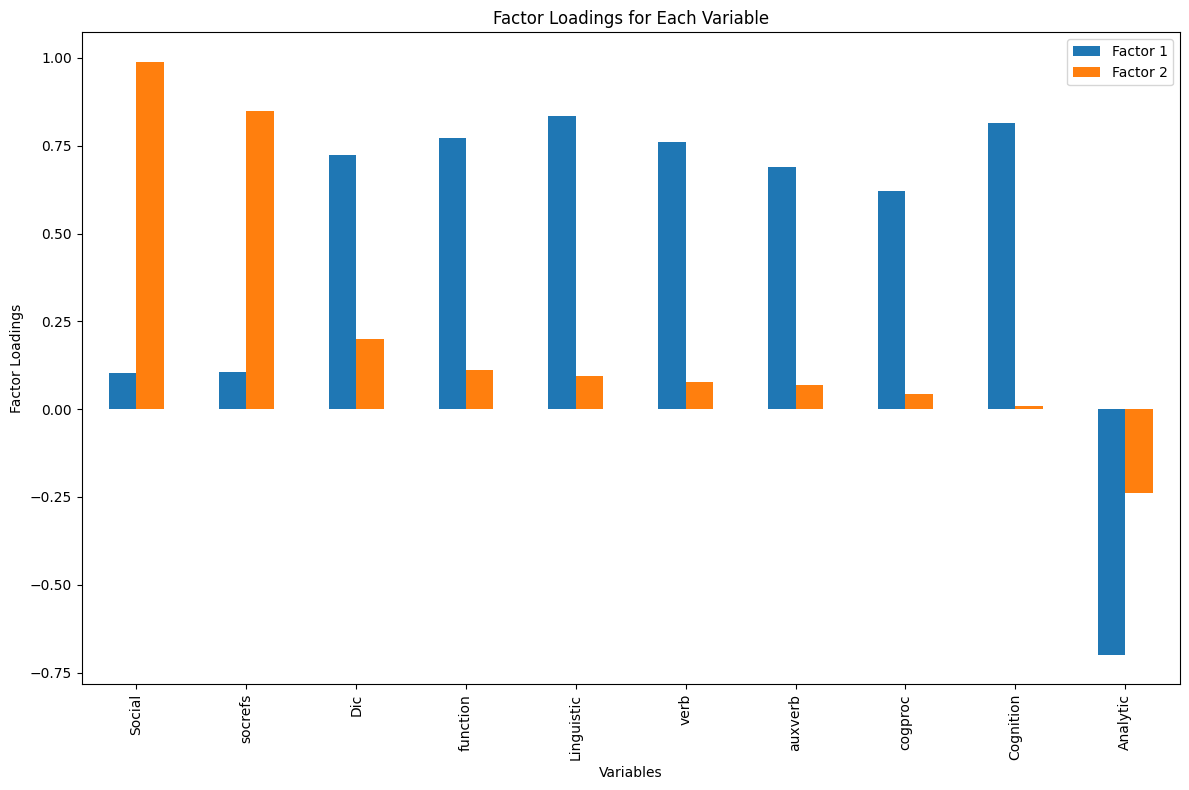

In [109]:
# look at loadings
import seaborn as sns

loadings = fa.loadings_

# Create a DataFrame for factor loadings for easier visualization
loadings_df = pd.DataFrame(loadings, columns=[f'Factor {i+1}' for i in range(loadings.shape[1])], index=scores_scaled.columns)
sorted_loadings_df = loadings_df.sort_values(by='Factor 2', ascending=False)


# Print factor loadings for each variable
print([sorted_loadings_df.head(10)])

# Plot bar chart of loadings for each variable in each factor
plt.figure(figsize=(10, 6))
# Set the axis limits for zooming in
sorted_loadings_df.plot(kind='bar', figsize=(12, 8))
plt.title("Factor Loadings for Each Variable")
plt.xlabel("Variables")
plt.ylabel("Factor Loadings")
plt.xticks(rotation=90)  # Rotate variable names for readability
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


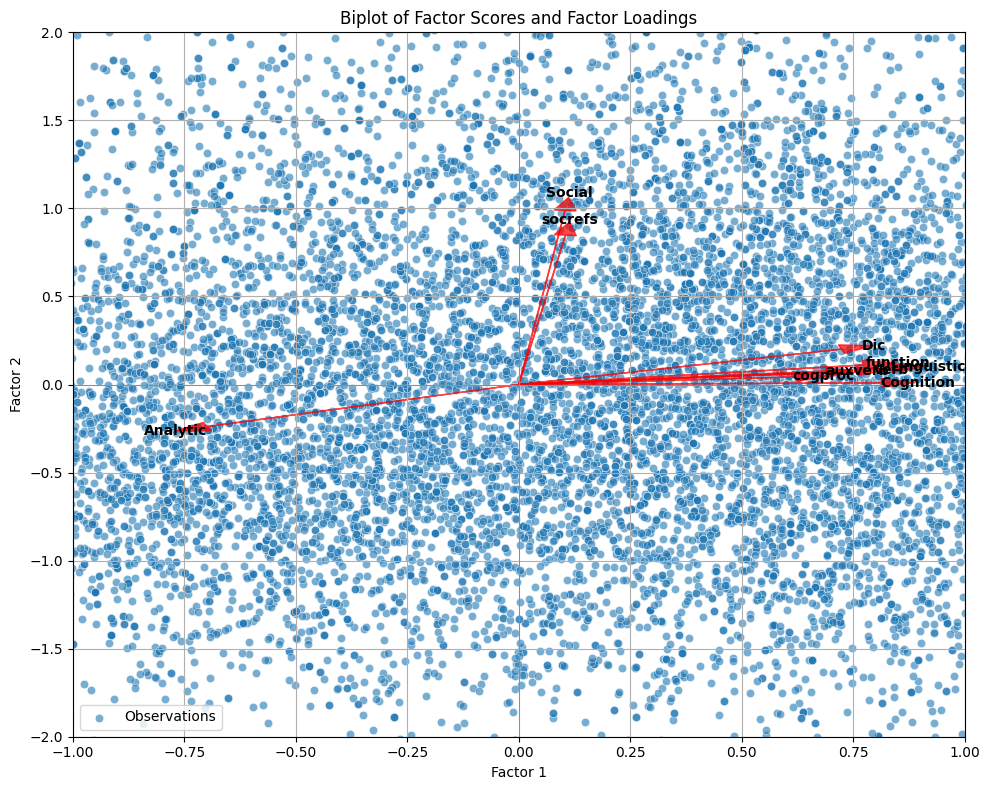

In [110]:
# look more at loadings and results: biplot
# biplot
import matplotlib.pyplot as plt
factor_scores = fa.transform(scores_scaled)

# Create a biplot: Factor scores (observations) and factor loadings (variables)
plt.figure(figsize=(10, 8))

# Plot factor scores
sns.scatterplot(x=factor_scores[:, 0], y=factor_scores[:, 1], alpha=0.6, label='Observations')

# Plot factor loadings (arrows for variables)
for i, var in enumerate(loadings_df.index):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='red', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, var, color='black', ha='center', va='center', fontweight='bold')

# Labels and title
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
# Set the axis limits for zooming in
plt.xlim(-1, 1)
plt.ylim(-2, 2)
plt.title('Biplot of Factor Scores and Factor Loadings')
plt.axhline(0, color='gray',linewidth=0.5)
plt.axvline(0, color='gray',linewidth=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


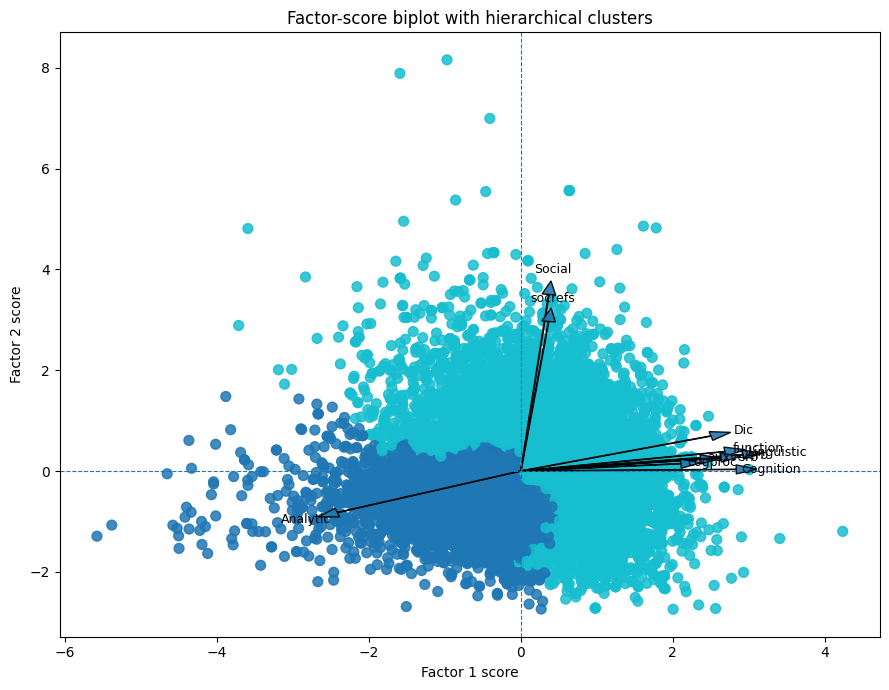

In [112]:
# Get factor scores and loadings
factor_scores = fa.transform(scores_scaled)
loadings = fa.loadings_[:, :2]
var_names = list(scores_scaled.columns)

# --- Add these lines ---
Z = linkage(factor_scores, method='ward')
clusters = fcluster(Z, t=2, criterion='maxclust')   # or use criterion='distance'
# -----------------------

# Plot
plt.figure(figsize=(9,7))
plt.scatter(factor_scores[:,0], factor_scores[:,1], c=clusters, cmap='tab10', s=50, alpha=0.85)
plt.axhline(0, linewidth=0.8, linestyle='--')
plt.axvline(0, linewidth=0.8, linestyle='--')
plt.xlabel("Factor 1 score")
plt.ylabel("Factor 2 score")
plt.title("Factor-score biplot with hierarchical clusters")

# Draw loading arrows
arrow_scale = 0.35 * np.max(np.ptp(factor_scores, axis=0))
for i, (lx, ly) in enumerate(loadings):
    plt.arrow(0, 0, lx*arrow_scale, ly*arrow_scale,
              width=0.008, head_width=0.18, length_includes_head=True, alpha=0.9)
    plt.text(lx*arrow_scale*1.06, ly*arrow_scale*1.06, var_names[i],
             fontsize=9, ha='center', va='center')

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


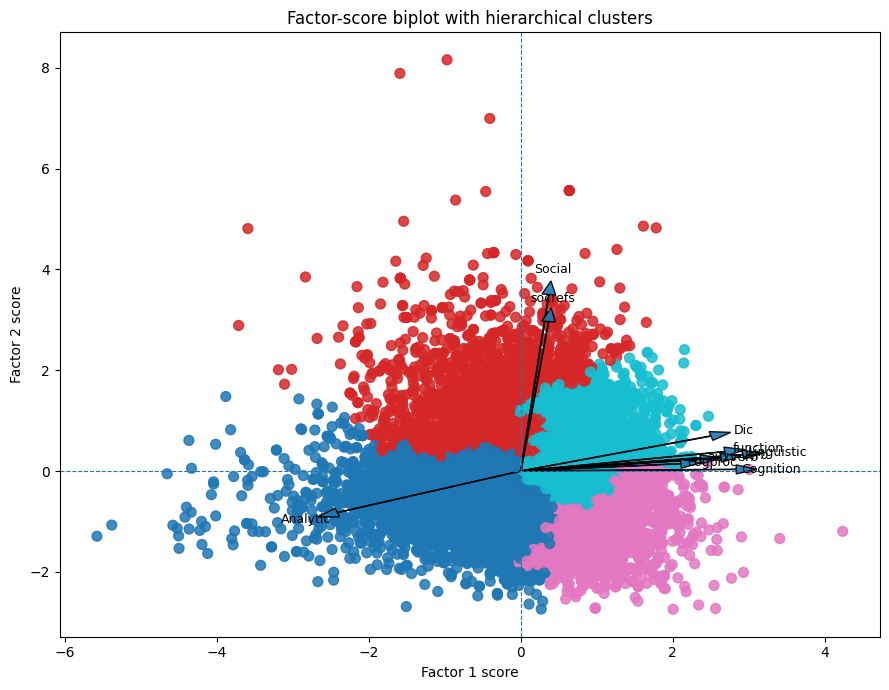

In [111]:
# Get factor scores and loadings
factor_scores = fa.transform(scores_scaled)
loadings = fa.loadings_[:, :2]
var_names = list(scores_scaled.columns)

# --- Add these lines ---
Z = linkage(factor_scores, method='ward')
clusters = fcluster(Z, t=4, criterion='maxclust')   # or use criterion='distance'
# -----------------------

# Plot
plt.figure(figsize=(9,7))
plt.scatter(factor_scores[:,0], factor_scores[:,1], c=clusters, cmap='tab10', s=50, alpha=0.85)
plt.axhline(0, linewidth=0.8, linestyle='--')
plt.axvline(0, linewidth=0.8, linestyle='--')
plt.xlabel("Factor 1 score")
plt.ylabel("Factor 2 score")
plt.title("Factor-score biplot with hierarchical clusters")

# Draw loading arrows
arrow_scale = 0.35 * np.max(np.ptp(factor_scores, axis=0))
for i, (lx, ly) in enumerate(loadings):
    plt.arrow(0, 0, lx*arrow_scale, ly*arrow_scale,
              width=0.008, head_width=0.18, length_includes_head=True, alpha=0.9)
    plt.text(lx*arrow_scale*1.06, ly*arrow_scale*1.06, var_names[i],
             fontsize=9, ha='center', va='center')

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


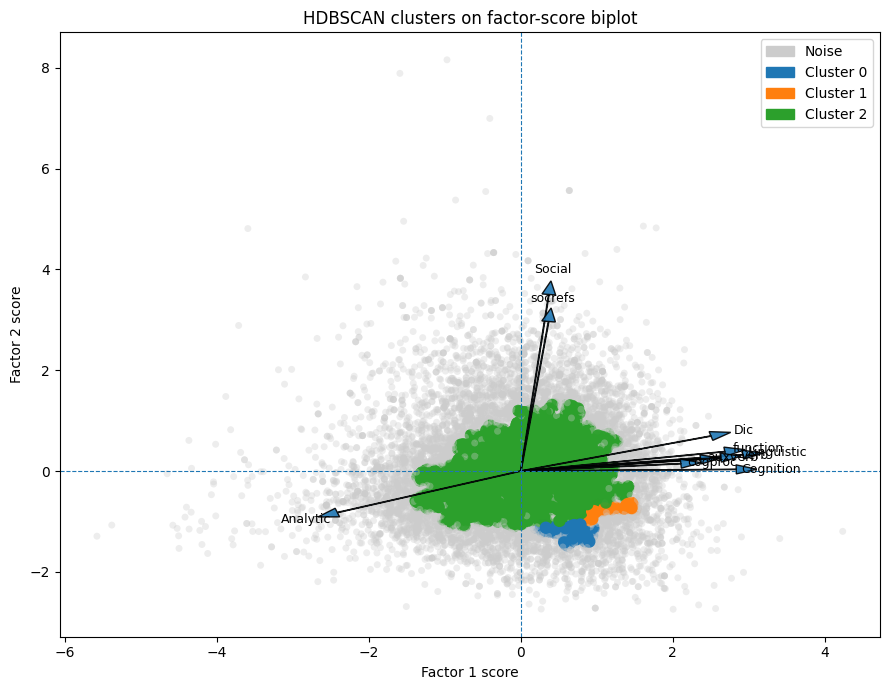

          n  avg_prob
label                
-1     6601  0.000000
 0      241  0.991993
 1      147  0.992505
 2     7973  0.982093


In [113]:
# --- HDBSCAN on factor scores + biplot with loadings ---

import hdbscan

# 1) Get factor scores (2D) and loadings from your fitted FactorAnalyzer `fa`
#    Assumes: fa.fit(pop_num_concise) was already done with n_factors=2
factor_scores = fa.transform(scores_scaled)      # shape: (n_samples, 2)
loadings = fa.loadings_[:, :2]                     # shape: (n_features, 2)
var_names = list(scores_scaled.columns)

# 2) Run HDBSCAN on the factor scores
#    Tune min_cluster_size / min_samples for your data density
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=120,      
    min_samples=5,         
    metric='euclidean',
    cluster_selection_method='eom'  # or 'leaf' for finer splits
)
labels = clusterer.fit_predict(factor_scores)      # -1 = noise
probs  = clusterer.probabilities_                  # membership strength in [0,1]

# 3) Build colors: one color per cluster, noise in light gray
unique_labels = np.unique(labels)
# Map labels (excluding -1) to tab10; noise -> lightgray
label_to_color = {}
palette = plt.cm.tab10.colors
ci = 0
for lab in unique_labels:
    if lab == -1:
        label_to_color[lab] = (0.8, 0.8, 0.8)      # light gray for noise
    else:
        label_to_color[lab] = palette[ci % len(palette)]
        ci += 1
colors = np.array([label_to_color[l] for l in labels])

# Optionally reflect membership strength in alpha/size
alphas = 0.35 + 0.65 * probs   # more confident points look bolder
sizes  = 25  + 55  * probs

# 4) Plot factor-score biplot colored by HDBSCAN clusters
plt.figure(figsize=(9, 7))
plt.scatter(
    factor_scores[:, 0], factor_scores[:, 1],
    c=colors, s=sizes, alpha=alphas, edgecolor='none'
)
plt.axhline(0, linewidth=0.8, linestyle='--')
plt.axvline(0, linewidth=0.8, linestyle='--')
plt.xlabel("Factor 1 score")
plt.ylabel("Factor 2 score")
plt.title("HDBSCAN clusters on factor-score biplot")

# 5) Overlay loading vectors (arrows) for interpretability
score_range = np.max(np.ptp(factor_scores, axis=0))
arrow_scale = 0.35 * score_range   # tweak if arrows too short/long

for i, (lx, ly) in enumerate(loadings):
    x_end = lx * arrow_scale
    y_end = ly * arrow_scale
    plt.arrow(0, 0, x_end, y_end,
              width=0.008, head_width=0.18,
              length_includes_head=True, alpha=0.9)
    plt.text(x_end * 1.06, y_end * 1.06, var_names[i],
             fontsize=9, ha='center', va='center')

# 6) Legend for clusters (including noise)
import matplotlib.patches as mpatches
handles = []
for lab in unique_labels:
    name = "Noise" if lab == -1 else f"Cluster {lab}"
    handles.append(mpatches.Patch(color=label_to_color[lab], label=name))
plt.legend(handles=handles, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# 7) (Optional) Inspect cluster sizes and confidences
import pandas as pd
summary = pd.DataFrame({
    "label": labels,
    "prob": probs
}).groupby("label").agg(n=("label", "size"), avg_prob=("prob", "mean")).sort_index()
print(summary)

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


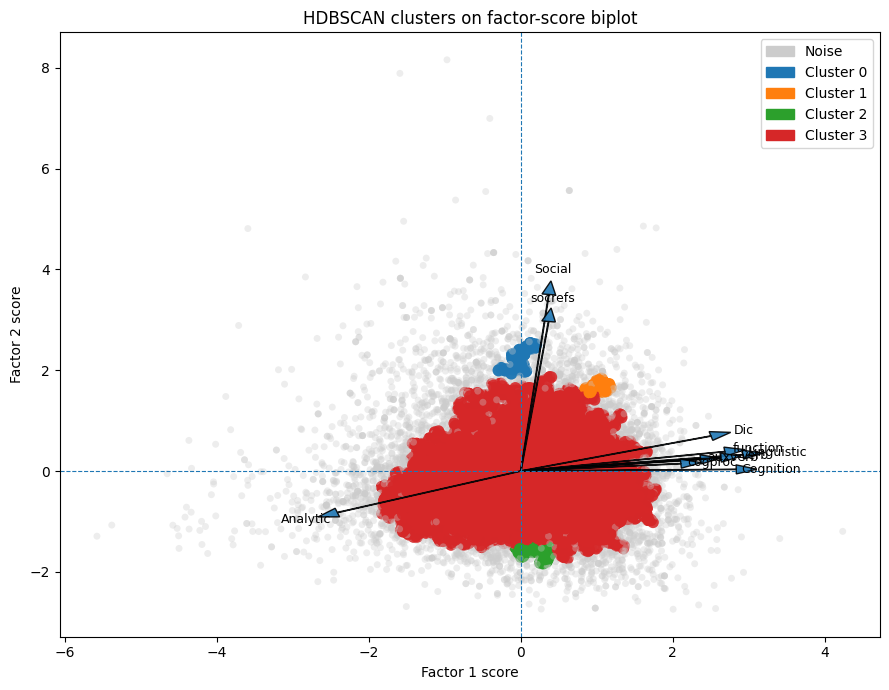

           n  avg_prob
label                 
-1      2959  0.000000
 0        62  0.995209
 1        40  1.000000
 2        87  0.994221
 3     11814  0.988130


In [114]:
# --- HDBSCAN on factor scores + biplot with loadings ---

# 1) Get factor scores (2D) and loadings from your fitted FactorAnalyzer `fa`
#    Assumes: fa.fit(pop_num_concise) was already done with n_factors=2
factor_scores = fa.transform(scores_scaled)      # shape: (n_samples, 2)
loadings = fa.loadings_[:, :2]                     # shape: (n_features, 2)
var_names = list(scores_scaled.columns)

# 2) Run HDBSCAN on the factor scores
#    Tune min_cluster_size / min_samples for your data density
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,      
    min_samples=5,         
    metric='euclidean',
    cluster_selection_method='eom'  # or 'leaf' for finer splits
)
labels = clusterer.fit_predict(factor_scores)      # -1 = noise
probs  = clusterer.probabilities_                  # membership strength in [0,1]

# 3) Build colors: one color per cluster, noise in light gray
unique_labels = np.unique(labels)
# Map labels (excluding -1) to tab10; noise -> lightgray
label_to_color = {}
palette = plt.cm.tab10.colors
ci = 0
for lab in unique_labels:
    if lab == -1:
        label_to_color[lab] = (0.8, 0.8, 0.8)      # light gray for noise
    else:
        label_to_color[lab] = palette[ci % len(palette)]
        ci += 1
colors = np.array([label_to_color[l] for l in labels])

# Optionally reflect membership strength in alpha/size
alphas = 0.35 + 0.65 * probs   # more confident points look bolder
sizes  = 25  + 55  * probs

# 4) Plot factor-score biplot colored by HDBSCAN clusters
plt.figure(figsize=(9, 7))
plt.scatter(
    factor_scores[:, 0], factor_scores[:, 1],
    c=colors, s=sizes, alpha=alphas, edgecolor='none'
)
plt.axhline(0, linewidth=0.8, linestyle='--')
plt.axvline(0, linewidth=0.8, linestyle='--')
plt.xlabel("Factor 1 score")
plt.ylabel("Factor 2 score")
plt.title("HDBSCAN clusters on factor-score biplot")

# 5) Overlay loading vectors (arrows) for interpretability
score_range = np.max(np.ptp(factor_scores, axis=0))
arrow_scale = 0.35 * score_range   # tweak if arrows too short/long

for i, (lx, ly) in enumerate(loadings):
    x_end = lx * arrow_scale
    y_end = ly * arrow_scale
    plt.arrow(0, 0, x_end, y_end,
              width=0.008, head_width=0.18,
              length_includes_head=True, alpha=0.9)
    plt.text(x_end * 1.06, y_end * 1.06, var_names[i],
             fontsize=9, ha='center', va='center')

# 6) Legend for clusters (including noise)
import matplotlib.patches as mpatches
handles = []
for lab in unique_labels:
    name = "Noise" if lab == -1 else f"Cluster {lab}"
    handles.append(mpatches.Patch(color=label_to_color[lab], label=name))
plt.legend(handles=handles, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# 7) (Optional) Inspect cluster sizes and confidences
import pandas as pd
summary = pd.DataFrame({
    "label": labels,
    "prob": probs
}).groupby("label").agg(n=("label", "size"), avg_prob=("prob", "mean")).sort_index()
print(summary)

### Correlation of Analytic, Linguistic, and Cognition

In [3]:
pop_large = pd.read_csv('songs_liwc.csv')

In [6]:
cols = ["Analytic", "Cognition", "Linguistic"]
corr_matrix = pop_large[cols].corr()
print(corr_matrix)

            Analytic  Cognition  Linguistic
Analytic    1.000000  -0.603323   -0.537843
Cognition  -0.603323   1.000000    0.549755
Linguistic -0.537843   0.549755    1.000000


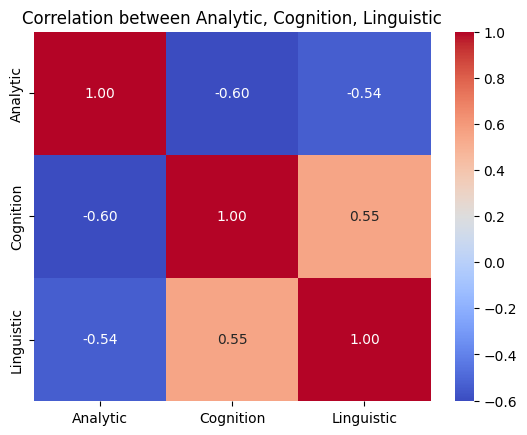

In [8]:
sns.heatmap(pop_large[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Analytic, Cognition, Linguistic")
plt.show()

In [10]:
pop = pd.read_csv('data/songs_kword_LIWC.csv')

In [11]:
cols = ["Analytic", "Cognition", "Linguistic"]
corr_matrix = pop[cols].corr()
print(corr_matrix)

            Analytic  Cognition  Linguistic
Analytic    1.000000  -0.530590   -0.546022
Cognition  -0.530590   1.000000    0.525103
Linguistic -0.546022   0.525103    1.000000


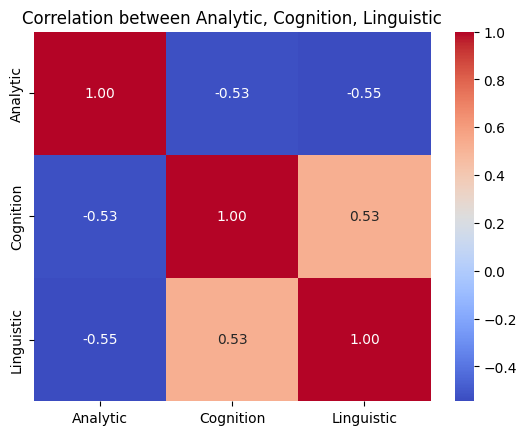

In [12]:
sns.heatmap(pop[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Analytic, Cognition, Linguistic")
plt.show()

In [3]:
office = pd.read_csv('counter_factual/office_liwc.csv')

In [4]:
cols = ["Analytic", "Cognition", "Linguistic"]
corr_matrix = office[cols].corr()
print(corr_matrix)

            Analytic  Cognition  Linguistic
Analytic    1.000000  -0.601052   -0.744731
Cognition  -0.601052   1.000000    0.580642
Linguistic -0.744731   0.580642    1.000000


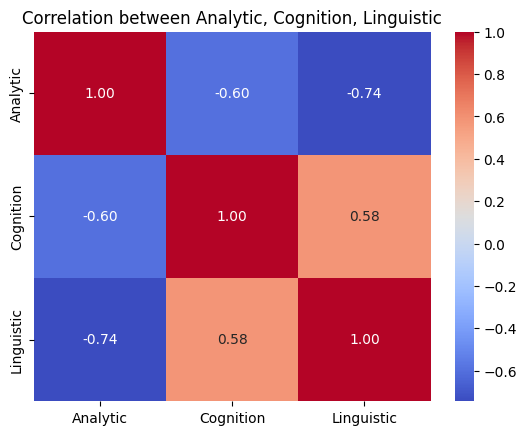

In [9]:
sns.heatmap(office[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Analytic, Cognition, Linguistic")
plt.show()